# Data Exploration

Explore the AI4Risk interbank network dataset (2016 Q1 - 2023 Q4).

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data import load_data
from src.models import (
    simulate_failure,
    compute_systemic_importance,
    degree_centrality,
    betweenness_centrality,
    closeness_centrality,
    eigenvector_centrality,
    weighted_degree,
    debtrank,
)

In [5]:
# Load all 32 quarters into individual DataFrames
rows = []

for year in range(2016, 2024):
    for q in range(1, 5):
        e, n = load_data(year, q)
        globals()[f"edges_{year}_Q{q}"] = e
        globals()[f"nodes_{year}_Q{q}"] = n
        rows.append({
            "year": year,
            "quarter": q,
            "period": f"{year} Q{q}",
            "n_banks": len(n),
            "n_edges": len(e),
        })

Loaded 2016 Q1: 4548 banks, 11631 edges
Loaded 2016 Q2: 4548 banks, 11632 edges
Loaded 2016 Q3: 4548 banks, 11937 edges
Loaded 2016 Q4: 4548 banks, 11938 edges
Loaded 2017 Q1: 4548 banks, 11939 edges
Loaded 2017 Q2: 4548 banks, 11940 edges
Loaded 2017 Q3: 4548 banks, 11941 edges
Loaded 2017 Q4: 4548 banks, 11981 edges
Loaded 2018 Q1: 4548 banks, 12416 edges
Loaded 2018 Q2: 4548 banks, 12417 edges
Loaded 2018 Q3: 4548 banks, 12418 edges
Loaded 2018 Q4: 4548 banks, 12419 edges
Loaded 2019 Q1: 4548 banks, 12420 edges
Loaded 2019 Q2: 4548 banks, 12421 edges
Loaded 2019 Q3: 4548 banks, 12422 edges
Loaded 2019 Q4: 4548 banks, 12423 edges
Loaded 2020 Q1: 4548 banks, 12424 edges
Loaded 2020 Q2: 4548 banks, 12451 edges
Loaded 2020 Q3: 4548 banks, 12452 edges
Loaded 2020 Q4: 4548 banks, 12453 edges
Loaded 2021 Q1: 4548 banks, 12454 edges
Loaded 2021 Q2: 4548 banks, 12455 edges
Loaded 2021 Q3: 4548 banks, 12456 edges
Loaded 2021 Q4: 4548 banks, 12457 edges
Loaded 2022 Q1: 4548 banks, 12458 edges


In [6]:
# Quick look at the first and last quarters
print("=== 2016 Q1 Edges ===")
display(edges_2016_Q1.head())

print("\n=== 2016 Q1 Nodes ===")
display(nodes_2016_Q1.head())

print("\n=== 2023 Q4 Edges ===")
display(edges_2023_Q4.head())

print("\n=== 2023 Q4 Nodes ===")
display(nodes_2023_Q4.head())

=== 2016 Q1 Edges ===


,Sourceid,Targetid,Weights
0,0,1,4440.0
1,0,2,3809.0
2,0,3,16011.0
3,0,4,16674.0
4,0,5,2779.0



=== 2016 Q1 Nodes ===


,index,Total_assets,Total_liabilities,Equity,Liquid_assets,Deposits_and_short-term_funding,Long-term_funding,Net_income,Interbank_assets,Interbank_liabilities,...,Total_equity_/_Total_liabilities_excluding_hybrid_capital_and_subordinated_liabilities,Capital_funds_/_Total_assets,Growth_in_gross_customer_loans_&advances,Capital_funds_/_Net_loans_&_advances_to_customers,Time_deposits,Non-interest_income_/_Operating_revenues,Net_interest_margin_(interest_earning_assets),rank_next_quarter,srisk_ratio,srisk_value
0,0,2.015718e+09,1.817839e+09,1.978790e+08,995459000.0,1.532137e+09,9.085800e+07,4197000.000,284783000.0,1.524420e+08,...,10.936928,10.241710,2.811964,27.750983,6.850800e+07,52.033698,2.730287,1,9.68,64677.6
1,1,1.653947e+09,1.445797e+09,2.081500e+08,520240000.0,1.363841e+09,2.511900e+07,3712000.000,47474000.0,5.042000e+07,...,14.459611,12.964140,0.608238,24.754956,6.492200e+07,40.143750,2.951758,3,11.93,79705.4
2,2,1.342643e+09,1.194543e+09,1.481000e+08,584455000.0,1.009545e+09,6.186300e+07,2879000.000,136395000.0,6.447600e+07,...,12.507992,11.812522,0.475133,27.814021,5.153900e+07,24.584387,3.803368,1,NaN,NaN
3,3,1.667785e+09,1.513099e+09,1.546860e+08,555658000.0,1.334370e+09,1.225960e+08,4735000.000,39389000.0,5.633200e+07,...,10.323970,10.161142,3.519757,18.935299,1.020940e+08,38.391164,3.497978,3,0.00,-6116.6
4,4,8.335113e+08,7.826065e+08,5.090483e+07,313991467.7,5.811292e+08,9.103480e+07,1578835.179,106306814.9,5.266122e+07,...,6.550267,6.762959,4.084363,13.596449,4.453125e+05,35.902972,2.223331,3,NaN,NaN



=== 2023 Q4 Edges ===


,Sourceid,Targetid,Weights
0,0,37,32.279364
1,0,77,216129.869906
2,0,89,11.360000
3,0,121,1677.721600
4,0,185,22840.382978



=== 2023 Q4 Nodes ===


,index,Total_assets,Total_liabilities,Equity,Liquid_assets,Deposits_and_short-term_funding,Long-term_funding,Net_income,Interbank_assets,Interbank_liabilities,...,Profit_attributable_to_group_equity_holders,Interest_income_on_customer_loans_&_advances,Total_other_earning_assets,Total_equity_/_Total_liabilities_excluding_hybrid_capital_and_subordinated_liabilities,Capital_funds_/_Total_assets,Growth_in_gross_customer_loans_&advances,Capital_funds_/_Net_loans_&_advances_to_customers,Time_deposits,Non-interest_income_/_Operating_revenues,Net_interest_margin_(interest_earning_assets)
0,0,3.395126e+09,3.095803e+09,2.993230e+08,1.409532e+09,2.632982e+09,181884000.0,8609000.000,335562000.0,160398000.0,...,8610000.000,23216000.00,1.297303e+09,9.669467,8.823767,1.024511,23.245608,292404000.0,30.920738,4.438297
1,1,2.540116e+09,2.303910e+09,2.362060e+08,6.981110e+08,2.185351e+09,37300000.0,4591000.000,75968000.0,153009000.0,...,4591000.000,15412000.00,1.069991e+09,10.258969,9.357132,0.224028,23.055978,152493000.0,23.218789,2.990640
2,2,1.684710e+09,1.520999e+09,1.637110e+08,6.522330e+08,1.371838e+09,41969000.0,-517000.000,105832000.0,81857000.0,...,-578000.000,14671000.00,7.163330e+08,10.838206,10.340711,3.492659,27.489696,129763000.0,17.881500,3.801693
3,3,1.733244e+09,1.570242e+09,1.630020e+08,4.484550e+08,1.446506e+09,69275000.0,3958000.000,75876000.0,27760000.0,...,3956000.000,14615000.00,5.552650e+08,10.447420,9.983072,-0.527822,19.516286,195576000.0,27.659235,4.022865
4,4,1.410874e+09,1.330053e+09,8.082114e+07,6.257934e+08,1.043950e+09,141745366.8,2080599.795,218211374.4,150915578.0,...,1939297.799,4245548.23,7.026977e+08,6.108385,6.220005,2.958175,13.325109,153735129.5,37.503127,1.880460


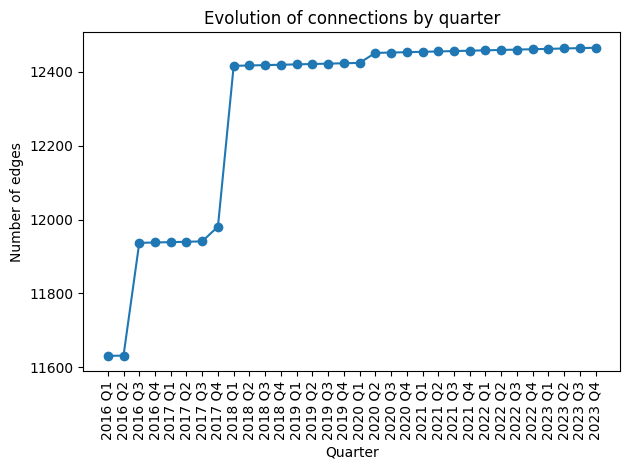

In [9]:
df_evolution = pd.DataFrame(rows).sort_values(["year", "quarter"]).reset_index(drop=True)
df_evolution["delta_edges"] = df_evolution["n_edges"].diff()

# Plot 1: Edges over time
plt.figure()
plt.plot(df_evolution["period"], df_evolution["n_edges"], marker="o")
plt.xticks(rotation=90)
plt.xlabel("Quarter")
plt.ylabel("Number of edges")
plt.title("Evolution of connections by quarter")
plt.tight_layout()
plt.show()


In [21]:
# for loop to have the basic stats of each quarter and concatenate them into a single DataFrame
stats_rows = []

for year in range(2016, 2024):
    for q in range(1, 5):
        n = globals()[f"nodes_{year}_Q{q}"]

        # select only numeric financial features
        num_cols = n.select_dtypes(include="number").drop(columns=["index"], errors="ignore")

        # describe for this quarter
        desc = num_cols.describe().T.reset_index()
        desc = desc.rename(columns={"index": "feature"})

        # add time information
        desc["year"] = year
        desc["quarter"] = q
        desc["period"] = f"{year} Q{q}"
        desc["n_banks"] = len(n)

        stats_rows.append(desc)

# concatenating the stats into a single dataframe
df_node_stats = pd.concat(stats_rows, ignore_index=True)

display(df_node_stats.head(-5))
print(df_node_stats.shape)

,feature,count,mean,std,min,25%,50%,75%,max,year,quarter,period,n_banks
0,Total_assets,4548.0,6.335496e+06,6.155170e+07,0.000000e+00,93289.250000,192646.500000,469170.000000,2.015718e+09,2016,1,2016 Q1,4548
1,Total_liabilities,4548.0,5.751365e+06,5.591334e+07,0.000000e+00,81317.500000,169584.500000,417608.750000,1.817839e+09,2016,1,2016 Q1,4548
2,Equity,4548.0,5.764525e+05,5.883081e+06,0.000000e+00,10731.500000,22106.000000,54308.750000,2.081500e+08,2016,1,2016 Q1,4548
3,Liquid_assets,4548.0,2.023994e+06,2.490484e+07,0.000000e+00,23622.500000,52625.000000,125288.750000,9.954590e+08,2016,1,2016 Q1,4548
4,Deposits_and_short-term_funding,4548.0,4.543275e+06,4.537772e+07,0.000000e+00,79113.500000,164682.000000,405300.500000,1.532137e+09,2016,1,2016 Q1,4548
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2319,Profit_attributable_to_group_equity_holders,4548.0,2.246488e+04,2.245993e+05,-4.938000e+06,183.000000,686.500000,2138.000000,8.610000e+06,2023,4,2023 Q4,4548
2320,Interest_income_on_customer_loans_&_advances,4548.0,9.622044e+04,7.802511e+05,-1.355200e+04,1200.750000,3110.000000,8892.750000,2.321600e+07,2023,4,2023 Q4,4548
2321,Total_other_earning_assets,4548.0,3.333167e+06,3.601813e+07,0.000000e+00,41415.500000,92060.500000,233455.250000,1.297303e+09,2023,4,2023 Q4,4548
2322,Total_equity_/_Total_liabilities_excluding_hyb...,4548.0,1.296195e+02,4.849337e+03,-4.296288e+00,8.565743,10.552866,13.464668,3.040000e+05,2023,4,2023 Q4,4548


(2329, 13)


In [ ]:
import pandas as pd
import numpy as np

# import your functions (adapt path)
# from src.models.classical_algorithms import (
#     degree_centrality, betweenness_centrality, closeness_centrality,
#     eigenvector_centrality, weighted_degree, debtrank
# )

def gini(x: pd.Series) -> float:
    x = x.dropna().astype(float).values
    if x.size == 0:
        return np.nan
    x = np.sort(x)
    if np.all(x == 0):
        return 0.0
    n = x.size
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

def summarize_metric(df: pd.DataFrame, col: str) -> dict:
    s = df[col].astype(float)
    return {
        f"{col}_mean": s.mean(),
        f"{col}_median": s.median(),
        f"{col}_p95": s.quantile(0.95),
        f"{col}_max": s.max(),
        f"{col}_top1_share": (s.nlargest(max(1, int(0.01 * len(s)))).sum() / (s.sum() + 1e-12)),
        f"{col}_gini": gini(s),
    }

quarter_rows = []

for year in range(2016, 2024):
    for q in range(1, 5):
        edges = globals()[f"edges_{year}_Q{q}"]
        nodes = globals()[f"nodes_{year}_Q{q}"]

        # Classical Algorithm measures 
        deg_df  = degree_centrality(edges, nodes)
        wdeg_df = weighted_degree(edges, nodes)

    
        bet_df  = betweenness_centrality(edges, nodes)
        clo_df  = closeness_centrality(edges, nodes)
        eig_df  = eigenvector_centrality(edges, nodes)
        dr_df   = debtrank(edges, nodes)

        row = {
            "year": year,
            "quarter": q,
            "period": f"{year} Q{q}",
            "n_banks": len(nodes),
            "n_edges": len(edges),
        }

        # Summaries 
        row.update(summarize_metric(deg_df, "degree_centrality"))
        row.update(summarize_metric(wdeg_df, "weighted_degree_total"))
        row.update(summarize_metric(wdeg_df, "weighted_degree_in"))
        row.update(summarize_metric(wdeg_df, "weighted_degree_out"))

        
        row.update(summarize_metric(bet_df, "betweenness_centrality"))
        row.update(summarize_metric(clo_df, "closeness_centrality"))
        row.update(summarize_metric(eig_df, "eigenvector_centrality"))
        row.update(summarize_metric(dr_df,  "debtrank"))

        quarter_rows.append(row)

df_network_descriptive = (
    pd.DataFrame(quarter_rows)
      .sort_values(["year", "quarter"])
      .reset_index(drop=True)
)

display(df_network_descriptive)